# 07 - Inference Demo

This notebook demonstrates the complete end-to-end stamp verification system on individual images and a small batch. It combines the full detection and classification pipeline into a single `run_stamp_inference` function that takes a raw document image and returns a verdict - **GENUINE** or **FORGED** - along with the confidence score and inference time.

**Input:** Raw scanned document images  
**Model:** `outputs/models/stamp_resnet50_final.keras`  
**Decision threshold:** `BEST_THRESHOLD = 0.25` (determined in notebook 06)

---
## Contents
1. Imports
2. Configuration
3. Helper: `show_image`
4. Function: `contour_stamp_score`
5. Function: `find_stamp_candidates_by_contours`
6. Function: `extract_roi_from_candidate_original`
7. Load model
8. Function: `preprocess_roi_for_model`
9. Function: `run_stamp_inference` - full end-to-end pipeline
10. Single image demo
11. Visualise detection and prediction
12. Print verification result
13. Batch demo - 5 genuine + 5 forged
14. Batch accuracy summary


In [9]:
from pathlib import Path
import time

import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.applications.resnet50 import preprocess_input

## 1. Imports

Same libraries as previous notebooks with the addition of `time` - used to measure inference time per image.

In [22]:
DATASET_ROOT = Path(
    r"D:\OneDrive - engug.ruh.ac.lk\2. Semester 7\EC7205 - IMAGE PROCESSING AND COMPUTER VISION\1. Project\dataset_raw"
)

MODEL_PATH = Path("../outputs/models/stamp_resnet50_final.keras")

IMG_SIZE = 224
DISPLAY_WIDTH = 900

BEST_THRESHOLD = 0.25

## 2. Configuration

| Variable | Value | Description |
|---|---|---|
| `DATASET_ROOT` | local path | Raw scanned document images for demo |
| `MODEL_PATH` | `../outputs/models/stamp_resnet50_final.keras` | Trained model |
| `IMG_SIZE` | 224 | Input size expected by ResNet50 |
| `DISPLAY_WIDTH` | 900 | Width to resize documents for detection |
| `BEST_THRESHOLD` | 0.25 | Decision threshold from notebook 06 - probabilities above this are classified as forged |

> ⚠️ Update `DATASET_ROOT` to your local path before running.


In [23]:
def show_image(title, image, cmap=None, figsize=(8, 10)):
    plt.figure(figsize=figsize)
    plt.imshow(image, cmap=cmap)
    plt.title(title)
    plt.axis("off")
    plt.show()

## 3. Helper Function - `show_image`

Reusable display function used throughout this notebook to show images with a title.

In [24]:
def contour_stamp_score(contour):
    area = cv2.contourArea(contour)

    if area < 80:
        return None

    x, y, w, h = cv2.boundingRect(contour)

    if w == 0 or h == 0:
        return None

    aspect_ratio = w / h
    compactness = min(w, h) / max(w, h)

    perimeter = cv2.arcLength(contour, True)

    if perimeter == 0:
        return None

    circularity = (4 * np.pi * area) / (perimeter**2)

    bbox_area = w * h
    density = area / bbox_area if bbox_area > 0 else 0

    if compactness < 0.45:
        return None

    if density < 0.08:
        return None

    score = 0.45 * compactness + 0.35 * circularity + 0.20 * density

    return {
        "x": int(x),
        "y": int(y),
        "w": int(w),
        "h": int(h),
        "area": float(area),
        "aspect_ratio": float(aspect_ratio),
        "compactness": float(compactness),
        "circularity": float(circularity),
        "density": float(density),
        "score": float(score),
    }

## 4. Function - `contour_stamp_score`

Scores a contour by circularity, compactness, and density. Rejects contours with area < 80 px², compactness < 0.45, or density < 0.08. Returns a dict of shape metrics and a weighted score.


In [25]:
def find_stamp_candidates_by_contours(image_bgr, display_width=900):
    original_h, original_w = image_bgr.shape[:2]

    scale = display_width / original_w
    resized_h = int(original_h * scale)

    image_resized = cv2.resize(image_bgr, (display_width, resized_h))

    image_hsv = cv2.cvtColor(image_resized, cv2.COLOR_BGR2HSV)

    h = image_hsv[:, :, 0]
    s = image_hsv[:, :, 1]
    v = image_hsv[:, :, 2]

    hue_mask = cv2.inRange(h, 90, 170)
    sat_mask = cv2.inRange(s, 25, 255)
    val_mask = cv2.inRange(v, 30, 255)

    mask = cv2.bitwise_and(hue_mask, sat_mask)
    mask = cv2.bitwise_and(mask, val_mask)

    kernel_open = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))

    kernel_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (11, 11))

    mask_opened = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel_open)

    mask_cleaned = cv2.morphologyEx(mask_opened, cv2.MORPH_CLOSE, kernel_close)

    contours, _ = cv2.findContours(
        mask_cleaned, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )

    candidates = []

    for contour in contours:
        result = contour_stamp_score(contour)

        if result is not None:
            candidates.append(result)

    candidates = sorted(candidates, key=lambda item: item["score"], reverse=True)

    return image_resized, mask_cleaned, candidates

## 5. Function - `find_stamp_candidates_by_contours`

Runs the full HSV → morphology → contour pipeline on a raw document image and returns ranked stamp candidates. 

**Returns:** `(image_resized, mask_cleaned, candidates)`


In [26]:
def extract_roi_from_candidate_original(
    original_image, resized_image, candidate, pad_factor=1.0
):
    original_h, original_w = original_image.shape[:2]
    resized_h, resized_w = resized_image.shape[:2]

    scale_x = original_w / resized_w
    scale_y = original_h / resized_h

    x, y, w, h = candidate["x"], candidate["y"], candidate["w"], candidate["h"]

    pad_x = int(w * pad_factor)
    pad_y = int(h * pad_factor)

    x1 = max(x - pad_x, 0)
    y1 = max(y - pad_y, 0)
    x2 = min(x + w + pad_x, resized_w)
    y2 = min(y + h + pad_y, resized_h)

    ox1 = int(x1 * scale_x)
    oy1 = int(y1 * scale_y)
    ox2 = int(x2 * scale_x)
    oy2 = int(y2 * scale_y)

    roi_original = original_image[oy1:oy2, ox1:ox2]

    bbox_original = (ox1, oy1, ox2, oy2)

    return roi_original, bbox_original

## 6. Function - `extract_roi_from_candidate_original`

Converts the detected bounding box from resized image coordinates back to original full-resolution coordinates and crops the ROI.

**Returns:** `(roi_bgr, bbox_original)`


In [27]:
model = tf.keras.models.load_model(MODEL_PATH)

print("Model loaded successfully")
print("Using decision threshold:", BEST_THRESHOLD)

Model loaded successfully
Using decision threshold: 0.25


## 7. Load Model

Loads the trained ResNet50 model and prints the decision threshold that will be applied to its output probabilities.


In [28]:
def preprocess_roi_for_model(roi_bgr):
    roi_rgb = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2RGB)

    roi_resized = cv2.resize(
        roi_rgb, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA
    )

    roi_array = roi_resized.astype(np.float32)
    roi_array = preprocess_input(roi_array)

    roi_array = np.expand_dims(roi_array, axis=0)

    return roi_array, roi_resized

## 8. Function - `preprocess_roi_for_model`

Prepares a cropped ROI for model input:
1. Converts BGR to RGB
2. Resizes to 224×224 using `INTER_AREA` interpolation
3. Converts to `float32`
4. Applies ResNet50 normalisation via `preprocess_input`
5. Adds a batch dimension with `np.expand_dims` - model expects shape `(1, 224, 224, 3)`

**Returns:** `(roi_array, roi_display_rgb)` - the normalised model input and the RGB display version


In [29]:
def run_stamp_inference(image_path):
    start_time = time.time()

    image_bgr = cv2.imread(str(image_path))

    if image_bgr is None:
        raise ValueError(f"Could not read image: {image_path}")

    image_resized, mask_cleaned, candidates = find_stamp_candidates_by_contours(
        image_bgr, display_width=DISPLAY_WIDTH
    )

    if len(candidates) == 0:
        return {"success": False, "reason": "No stamp candidate found"}

    best_candidate = candidates[0]

    roi_bgr, bbox_original = extract_roi_from_candidate_original(
        original_image=image_bgr,
        resized_image=image_resized,
        candidate=best_candidate,
        pad_factor=1.0,
    )

    model_input, roi_display_rgb = preprocess_roi_for_model(roi_bgr)

    forged_probability = float(model.predict(model_input, verbose=0)[0][0])

    predicted_label = "forged" if forged_probability >= BEST_THRESHOLD else "genuine"

    confidence = (
        forged_probability if predicted_label == "forged" else 1 - forged_probability
    )

    end_time = time.time()
    inference_time = end_time - start_time

    return {
        "success": True,
        "image_bgr": image_bgr,
        "image_resized": image_resized,
        "mask_cleaned": mask_cleaned,
        "candidates": candidates,
        "best_candidate": best_candidate,
        "roi_bgr": roi_bgr,
        "roi_display_rgb": roi_display_rgb,
        "bbox_original": bbox_original,
        "forged_probability": forged_probability,
        "predicted_label": predicted_label,
        "confidence": confidence,
        "inference_time": inference_time,
    }

## 9. Function - `run_stamp_inference`

The complete end-to-end inference function. Given a raw document image path it:

1. Reads the image with `cv2.imread`
2. Runs `find_stamp_candidates_by_contours` to detect the stamp region
3. Extracts the ROI at full resolution with `extract_roi_from_candidate_original`
4. Preprocesses the ROI with `preprocess_roi_for_model`
5. Runs the model to get `forged_probability`
6. Applies `BEST_THRESHOLD` to produce `predicted_label` - `"forged"` or `"genuine"`
7. Calculates `confidence` - how far the probability is from the threshold
8. Measures total `inference_time` from image load to prediction

**Returns:** a dict containing the prediction result, all intermediate outputs, and timing information - or `{"success": False}` if no stamp is detected


In [30]:
sample_path = Path(
    r"D:\OneDrive - engug.ruh.ac.lk\2. Semester 7\EC7205 - IMAGE PROCESSING AND COMPUTER VISION\1. Project\dataset_raw\class_1_forged\inkjet\Gen_A_300dpi_008.png"
)

result = run_stamp_inference(sample_path)

print("Success:", result["success"])

if result["success"]:
    print("Prediction:", result["predicted_label"].upper())
    print("Forged probability:", result["forged_probability"])
    print("Confidence:", result["confidence"])
    print("Inference time:", result["inference_time"], "seconds")
else:
    print("Reason:", result["reason"])

Success: True
Prediction: FORGED
Forged probability: 0.43174004554748535
Confidence: 0.43174004554748535
Inference time: 7.590359926223755 seconds


## 10. Single Image Demo

Runs `run_stamp_inference` on one sample image and prints the prediction, forged probability, confidence, and inference time.

> ⚠️ Update `sample_path` to a valid image from your dataset.


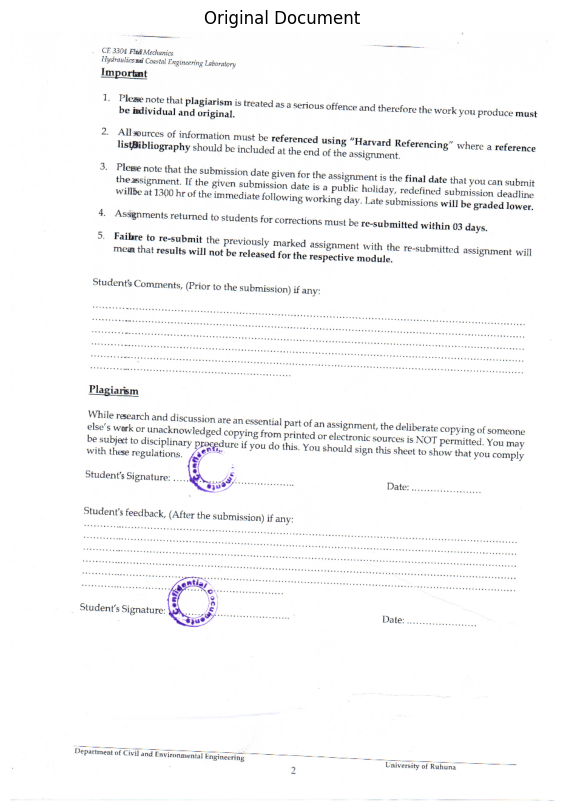

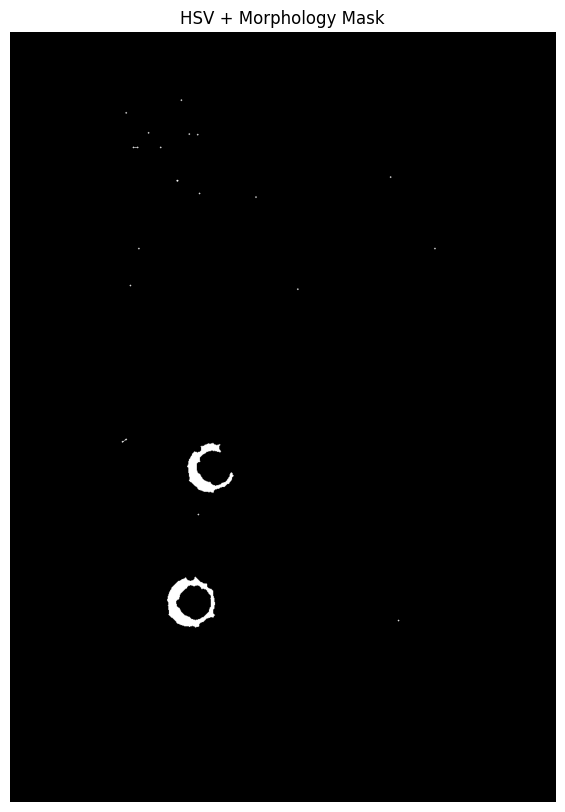

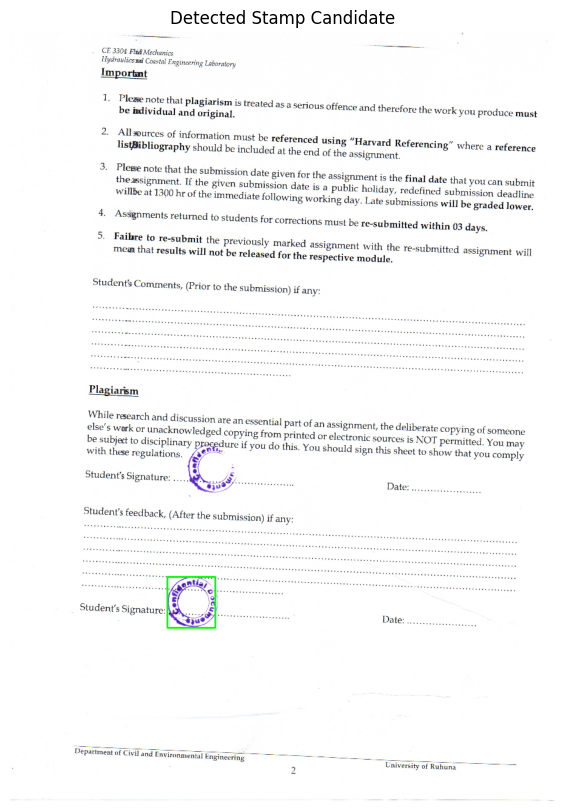

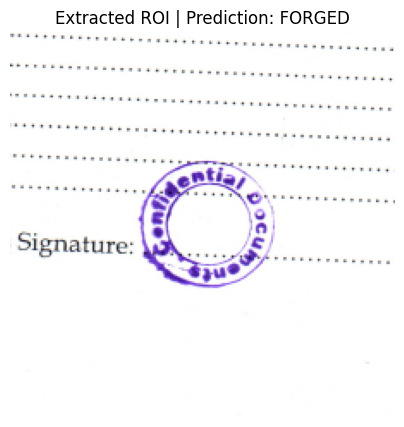

In [31]:
if result["success"]:
    image_rgb = cv2.cvtColor(result["image_resized"], cv2.COLOR_BGR2RGB)

    output = result["image_resized"].copy()

    c = result["best_candidate"]

    x, y, w, h = c["x"], c["y"], c["w"], c["h"]

    cv2.rectangle(output, (x, y), (x + w, y + h), (0, 255, 0), 2)

    output_rgb = cv2.cvtColor(output, cv2.COLOR_BGR2RGB)

    show_image("Original Document", image_rgb, figsize=(8, 10))

    show_image(
        "HSV + Morphology Mask", result["mask_cleaned"], cmap="gray", figsize=(8, 10)
    )

    show_image("Detected Stamp Candidate", output_rgb, figsize=(8, 10))

    show_image(
        f"Extracted ROI | Prediction: {result['predicted_label'].upper()}",
        result["roi_display_rgb"],
        figsize=(5, 5),
    )

## 10. Visualise Detection and Prediction

Displays four images from the inference result:
1. **Original document** - the full resized document
2. **HSV + Morphology Mask** - the binary mask showing detected stamp ink pixels
3. **Detected Stamp Candidate** - the original document with a green bounding box around the detected stamp
4. **Extracted ROI** - the cropped stamp region with the prediction label as the title


In [32]:
if result["success"]:
    print("=" * 50)
    print("STAMP VERIFICATION RESULT")
    print("=" * 50)
    print(f"Input image        : {sample_path.name}")
    print(f"Prediction         : {result['predicted_label'].upper()}")
    print(f"Forged probability : {result['forged_probability']:.4f}")
    print(f"Decision threshold : {BEST_THRESHOLD}")
    print(f"Confidence         : {result['confidence']:.4f}")
    print(f"Inference time     : {result['inference_time']:.4f} seconds")
    print("=" * 50)

STAMP VERIFICATION RESULT
Input image        : Gen_A_300dpi_008.png
Prediction         : FORGED
Forged probability : 0.4317
Decision threshold : 0.25
Confidence         : 0.4317
Inference time     : 7.5904 seconds


## 11. Print Verification Result

Prints a formatted summary of the verification outcome including the prediction, forged probability, decision threshold, confidence, and inference time.


In [33]:
import pandas as pd


test_images = (
    list((DATASET_ROOT / "class_0_genuine").rglob("*.png"))[:5]
    + list((DATASET_ROOT / "class_1_forged").rglob("*.png"))[:5]
)

batch_results = []

for img_path in test_images:
    result = run_stamp_inference(img_path)

    if result["success"]:
        batch_results.append(
            {
                "image_name": img_path.name,
                "actual_class": (
                    "genuine" if "class_0_genuine" in str(img_path) else "forged"
                ),
                "predicted_class": result["predicted_label"],
                "forged_probability": result["forged_probability"],
                "confidence": result["confidence"],
                "inference_time": result["inference_time"],
            }
        )
    else:
        batch_results.append(
            {
                "image_name": img_path.name,
                "actual_class": (
                    "genuine" if "class_0_genuine" in str(img_path) else "forged"
                ),
                "predicted_class": "failed",
                "forged_probability": None,
                "confidence": None,
                "inference_time": None,
            }
        )

df_batch_results = pd.DataFrame(batch_results)

df_batch_results

,image_name,actual_class,predicted_class,forged_probability,confidence,inference_time
0,Gen_A_300dpi_001.png,genuine,genuine,0.189286,0.810714,0.682873
1,Gen_A_300dpi_002.png,genuine,forged,0.782063,0.782063,0.649584
2,Gen_A_300dpi_003.png,genuine,forged,0.491447,0.491447,0.809123
3,Gen_A_300dpi_004.png,genuine,forged,0.542337,0.542337,0.705290
4,Gen_A_300dpi_005.png,genuine,forged,0.500429,0.500429,0.629277
5,Gen_A_300dpi_002.png,forged,forged,0.782063,0.782063,0.652431
6,Gen_A_300dpi_004.png,forged,forged,0.542337,0.542337,0.739483
7,Gen_A_300dpi_005.png,forged,forged,0.500429,0.500429,0.674716
8,Gen_A_300dpi_008.png,forged,forged,0.431740,0.431740,0.780325
9,Gen_A_300dpi_011.png,forged,forged,0.547255,0.547255,1.069865


## 12. Batch Demo - 5 Genuine + 5 Forged

Runs `run_stamp_inference` on 10 images (5 genuine, 5 forged) and collects the results into `df_batch_results`. Failed detections are recorded with `predicted_class = "failed"` so they are not silently dropped.


In [34]:
valid_results = df_batch_results[df_batch_results["predicted_class"] != "failed"].copy()

valid_results["correct"] = (
    valid_results["actual_class"] == valid_results["predicted_class"]
)

print("Batch demo accuracy:")
print(valid_results["correct"].mean())

valid_results

Batch demo accuracy:
0.6


,image_name,actual_class,predicted_class,forged_probability,confidence,inference_time,correct
0,Gen_A_300dpi_001.png,genuine,genuine,0.189286,0.810714,0.682873,True
1,Gen_A_300dpi_002.png,genuine,forged,0.782063,0.782063,0.649584,False
2,Gen_A_300dpi_003.png,genuine,forged,0.491447,0.491447,0.809123,False
3,Gen_A_300dpi_004.png,genuine,forged,0.542337,0.542337,0.705290,False
4,Gen_A_300dpi_005.png,genuine,forged,0.500429,0.500429,0.629277,False
5,Gen_A_300dpi_002.png,forged,forged,0.782063,0.782063,0.652431,True
6,Gen_A_300dpi_004.png,forged,forged,0.542337,0.542337,0.739483,True
7,Gen_A_300dpi_005.png,forged,forged,0.500429,0.500429,0.674716,True
8,Gen_A_300dpi_008.png,forged,forged,0.431740,0.431740,0.780325,True
9,Gen_A_300dpi_011.png,forged,forged,0.547255,0.547255,1.069865,True


## 13. Batch Accuracy Summary

Filters out failed detections and calculates the proportion of correct predictions across the 10 demo images. This is a quick sanity check - not a replacement for the full test set evaluation in notebook 06.
